In [2]:
import pathlib
import numpy as np
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
morpho_cashe = defaultdict(str)

# НОВАЯ ФУНКЦИЯ: Расчёт статистики глубины синтаксического дерева
def calc_depth_stat(book):
    """
    Рассчитывает статистику глубины синтаксического дерева для каждого предложения.
    Возвращает словарь с различными метриками глубины.
    """
    depths = []
    
    for sentence in book:
        if not sentence:
            continue
            
        # Шаг 1: Строим отображение child -> parent
        # И находим корни (узлы, у которых head = 0 или head None)
        parent_of = {}
        children_of = defaultdict(list)
        roots = []
        
        for word in sentence:
            word_id = word['id']
            head_id = word['head']
            
            if head_id is None or head_id == 0:
                # Это корневой узел
                roots.append(word_id)
                parent_of[word_id] = 0
            else:
                parent_of[word_id] = head_id
                children_of[head_id].append(word_id)
        
        # Шаг 2: Если нет явных корней, находим узел, который не является чьим-то ребенком
        if not roots:
            all_children = set(parent_of.values())
            all_nodes = set([w['id'] for w in sentence])
            roots = list(all_nodes - all_children)
        
        # Шаг 3: Вычисляем глубину каждого узла рекурсивно
        def calc_node_depth(node_id, current_depth, visited):
            if node_id in visited:
                return current_depth
            visited.add(node_id)
            
            max_depth = current_depth
            for child_id in children_of[node_id]:
                child_depth = calc_node_depth(child_id, current_depth + 1, visited)
                max_depth = max(max_depth, child_depth)
            
            return max_depth
        
        # Шаг 4: Для каждого корня вычисляем глубину и собираем все глубины узлов
        sent_depths = []
        for root in roots:
            visited = set()
            tree_depth = calc_node_depth(root, 1, visited)  # начинаем с 1 (корень)
            if tree_depth > 0:
                sent_depths.append(tree_depth)
        
        if sent_depths:
            depths.extend(sent_depths)
    
    # Шаг 5: Возвращаем различные статистики глубины
    if not depths:
        return {
            'mean_depth': 0.0,
            'max_depth': 0,
            'min_depth': 0,
            'std_depth': 0.0,
            'median_depth': 0,
            'total_trees': 0
        }
    
    depths_array = np.array(depths)
    
    return {
        'mean_depth': float(np.mean(depths_array)),
        'max_depth': int(np.max(depths_array)),
        'min_depth': int(np.min(depths_array)),
        'std_depth': float(np.std(depths_array)),
        'median_depth': int(np.median(depths_array)),
        'total_trees': len(depths)
    }

# АЛЬТЕРНАТИВНАЯ ФУНКЦИЯ: Глубина для каждого отдельного узла (средняя глубина всех узлов)
def calc_avg_node_depth_stat(book):
    """
    Рассчитывает среднюю глубину для каждого узла в дереве.
    Отличается от предыдущей тем, что измеряет глубину каждого слова от корня.
    """
    all_depths = []
    
    for sentence in book:
        if not sentence:
            continue
            
        # Строим parent mapping
        parent_of = {}
        roots = []
        
        for word in sentence:
            word_id = word['id']
            head_id = word['head']
            
            if head_id is None or head_id == 0:
                roots.append(word_id)
                parent_of[word_id] = 0
            else:
                parent_of[word_id] = head_id
        
        # Находим глубину каждого узла
        def get_depth(node_id, memo):
            if node_id in memo:
                return memo[node_id]
            if node_id == 0 or node_id not in parent_of:
                return 0
            parent = parent_of[node_id]
            depth = get_depth(parent, memo) + 1
            memo[node_id] = depth
            return depth
        
        depth_memo = {}
        for word in sentence:
            node_depth = get_depth(word['id'], depth_memo)
            all_depths.append(node_depth)
    
    if not all_depths:
        return {'mean_node_depth': 0.0, 'max_node_depth': 0, 'min_node_depth': 0}
    
    depths_array = np.array(all_depths)
    return {
        'mean_node_depth': float(np.mean(depths_array)),
        'max_node_depth': int(np.max(depths_array)),
        'min_node_depth': int(np.min(depths_array)),
        'std_node_depth': float(np.std(depths_array))
    }

# ФУНКЦИЯ: Распределение глубин (гистограмма)
def calc_depth_histogram_stat(book, max_depth=10):
    """
    Создаёт гистограмму глубин: сколько деревьев имеют глубину 1, 2, 3, ..., max_depth
    """
    depth_counts = defaultdict(int)
    
    for sentence in book:
        if not sentence:
            continue
            
        # Строим parent mapping
        parent_of = {}
        children_of = defaultdict(list)
        roots = []
        
        for word in sentence:
            word_id = word['id']
            head_id = word['head']
            
            if head_id is None or head_id == 0:
                roots.append(word_id)
                parent_of[word_id] = 0
            else:
                parent_of[word_id] = head_id
                children_of[head_id].append(word_id)
        
        if not roots:
            all_children = set(parent_of.values())
            all_nodes = set([w['id'] for w in sentence])
            roots = list(all_nodes - all_children)
        
        def calc_depth(node_id, current_depth, visited):
            if node_id in visited:
                return current_depth
            visited.add(node_id)
            
            max_depth = current_depth
            for child_id in children_of[node_id]:
                child_depth = calc_depth(child_id, current_depth + 1, visited)
                max_depth = max(max_depth, child_depth)
            return max_depth
        
        for root in roots:
            visited = set()
            tree_depth = calc_depth(root, 1, visited)
            if tree_depth > 0 and tree_depth <= max_depth:
                depth_counts[tree_depth] += 1
            elif tree_depth > max_depth:
                depth_counts[max_depth] += 1
    
    # Превращаем в словарь с фиксированными ключами
    result = {f'depth_{d}': depth_counts[d] for d in range(1, max_depth + 1)}
    total = sum(depth_counts.values())
    
    # Нормализуем (опционально)
    if total > 0:
        for k in result:
            result[k] /= total
    
    return result

# Существующая функция (оставлена без изменений)
def calc_syntax_stat(book):
    con_stat = defaultdict(int)
    overall = 0
    for sentence in book:
        overall += len(sentence)
        for child_position, word in enumerate(sentence):
            if word['head'] is None:
                continue
            parent_position = word['head'] - 1
            if parent_position == -1:
                continue
            if parent_position > child_position:
                d = '<-'
            else:
                d = '->'
            con_stat[f"({sentence[parent_position]['upos']}, {d}, {word['upos']}, {word['deprel']})"] += 1

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

def calc_homonymy_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            if morpho_cashe[word['form']] != '':
                con_stat[morpho_cashe[word['form']]] += 1
            else:
                res = morph.parse(word['form'])
                nfs = list(set(a.normal_form for a in res))
                poses = list(set(a.tag.POS for a in res))

                if len(nfs) > 1: # Ambigous by lemma
                    if len(poses) > 1:
                        con_stat['pos_lemma'] += 1
                        morpho_cashe[word['form']] = 'pos_lemma'
                    else:
                        con_stat['lemma'] += 1
                        morpho_cashe[word['form']] = 'lemma'
                else:
                    if len(poses) > 1:
                        con_stat['pos'] += 1
                        morpho_cashe[word['form']] = 'pos'
                    else:
                        if len(res) > 1:
                            con_stat['feat'] += 1
                            morpho_cashe[word['form']] = 'feat'
                        else:
                            con_stat['unambig'] += 1
                            morpho_cashe[word['form']] = 'unambig'


    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

# service_poses = {'ADVB', 'NPRO', 'PRED', 'PREP', 'CONJ', 'PRCL', 'INTJ'}
service_poses = {'ADV', 'PRON', 'ADP', 'CCONJ', 'SCONJ', 'PART', 'DET'}

def calc_service_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            if word['upos'] in service_poses:
                con_stat[f'{word["lemma"]}_{word["upos"]}'] +=1

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

def calc_char_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            res = Counter(word['form'])
            for c, f in res.items():
                con_stat[c] += f

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

class CONLLUParser:
    '''
    Собственный класс для разбора CONLLU файлов.
    Потому что стандартный какой-то очень медленный.
    '''
    sentences: list # Список предложения текста, содержащих синтаксическую информацию.
    texts: list # Список предложений в текстовой форме.

    def __init__(self):
        self.sentences = []
        self.texts = []

    # Превращает кортеж в словарь слова.
    def __make_wordform(self, word):
        res = dict()
        res['id'] = int(word[0])
        res['form'] = word[1]
        res['lemma'] = word[2]
        res['upos'] = word[3]
        res['head'] = int(word[6]) if len(word) > 6 and word[6] != '_' else None
        res['deprel'] = word[7] if len(word) > 7 else '_'
        return res

    def __read_sentence(self, lines, pos):
        ''' Возвращает предложение из списка строк lines, записанных в формате UD.
            Предложение находится начиная со строки с номером pos.
        '''
        sent = []
        text = ""
        while pos < len(lines) and lines[pos] != '' and lines[pos] != '\n':
            try:
              if lines[pos][0] != '#':
                  parts = lines[pos][:-2].split("\t")
                  if len(parts) >= 8:  # Убедимся, что у нас достаточно колонок
                      sent.append(self.__make_wordform(parts))
              elif lines[pos].startswith('# text = '):
                  text = lines[pos][9:]
            except:
              print(f"Exception: {lines[pos]}")
            pos += 1
        pos += 1
        return sent, text, pos

    # Считывает книгу в conllu из списка строк.
    def parse_conllu_lines(self, lines):
        self.sentences = []
        self.texts = []
        pos = 0
        while pos < len(lines):
            sent, text, pos = self.__read_sentence(lines, pos)
            if sent:  # Добавляем только непустые предложения
                self.sentences.append(sent)
                self.texts.append(text)

    # Считывает книгу в conllu из файла.
    def parse_conllu_file(self, filename):
        with open(filename, "rt", encoding='utf-8') as book_file:
            lines = book_file.readlines()
            self.parse_conllu_lines(lines)
            del lines

class WriterStorage:
    '''
        Класс служит для расчёта показателей, по коорым будет определяться авторство.
      Из модуля calc_stat_vectors выгружаются функции, которые считают параметры:
      частоты по синтаксису, грамматической неоднозначности, символам, служебным частям речи.
      ОН умеет сеарилизовать себя в json, потому что когда считаешь фрагментами по 10 предложений,
      по большой коллекции тебе мало 64Г оперативки.
    '''

    # Описание свойств
    book_authors: list # Список имён авторов по книгам.
    book_names: list # Список названий книг.
    authors_id: dict # Словарь соответствий фамилии автора и его идентификатора.
    book_author_id: list # Список идентификаторов авторов по книгам.
    parts_author_id: list # Список идентификаторов авторов по частям.
    book_no: list # Номер книги в списке.

    books_stat: list # Статистика по книгам в виде словаря.
    parts_stat: list # Статистика по частям в виде словаря.
    part_no: list # Номер части в книге.
    part_book_no: list # Номер книги соответствующей части.
    books_vect_dict: dict # Словарь признаков и их номеров в векторе по книгам в целом.
    books_vect: list # Векторы признаков по книгам в целом.
    parts_vect_dict: dict # Словарь признаков и их номеров в векторе по всем частям книг.
    parts_vect: list # Векторы признаков по частям книг.
    texts_by_parts: list # Тексты по частям.

    def __init__(self):
        self.book_names = []
        self.book_authors = []
        self.book_sentences = []
        self.authors_id = dict()

    # Словарь с функциями, которые используются для расчёта. Ключ передается в функцию в качестве параметра.
    __func_correspondence  = {
        'syntax': calc_syntax_stat,
        'service': calc_service_stat,
        'homonymy': calc_homonymy_stat,
        'char': calc_char_stat,
        'depth': calc_depth_stat,  # НОВАЯ ФУНКЦИЯ
        'node_depth': calc_avg_node_depth_stat,  # НОВАЯ ФУНКЦИЯ
        'depth_hist': calc_depth_histogram_stat  # НОВАЯ ФУНКЦИЯ
    }

    def calc_connections_distr(self, book, text, what='syntax', fragment_len=100, **kwargs):
        '''
           Функция расчёта параметров для одной книги.
           book: Текст книги с синтаксической разметкой, разделенный на предложения.
           text: Текст книги, разделенный на предложения. Нужен, чтобы можно было посмореть где что.
           what: Какие параметры надо считать. Определяет какая функция расчёта параметров будет вызвана.
           fragment_len: Длина фрагментов, на кототрые надо делить.
           Возвращает синтаксически рамеченные предложения и текст книги, разделенные фрагменты.
           Если fragment_len = -1, возвращает книгу целиком.
        '''
        # Проверка, есть ли у нас такой ключ.
        if what not in WriterStorage.__func_correspondence.keys():
            raise Exception(f'We calculate statistics for the followig keys: '
                            f'{", ".join(WriterStorage.__func_correspondence.keys())}')

        # Расчёт статистики.
        # Определяем по какой функции ведётся расчёт.
        calc_connections_stat = WriterStorage.__func_correspondence[what]

        # Для depth_hist может понадобиться max_depth
        if what == 'depth_hist' and 'max_depth' in kwargs:
            calc_connections_stat = lambda b: WriterStorage.__func_correspondence['depth_hist'](b, kwargs['max_depth'])
        elif what == 'depth_hist':
            calc_connections_stat = WriterStorage.__func_correspondence['depth_hist']

        # -1 означает,что стаисика считаеттся для книги в целом.
        if fragment_len == -1:
            distr = calc_connections_stat(book)
            texts = [[text]]
        # В проивном случае надо разделить книгу на фрагменты.
        else:
            distr = []
            texts = []
            for i in range(0, len(book), fragment_len):
                distr.append(calc_connections_stat(book[i: i+fragment_len]))
                texts.append(text[i: i+fragment_len])
        return distr, texts

    def make_vector(self, data, keys):
        ''' Возвращает данные, собранные в виде словаря data в виде вектора,
            Соблюдая при этом порядок следования параметров, задаваемого при помощи keys.
        '''
        vect = np.zeros((len(keys)))
        for key, val in data.items():
            if key in keys:  # Проверяем, что ключ существует
                vect[keys[key]] = val
        return vect

    def vectorize_data(self, data):
        '''
        Векторизует данные из словаря data.
        Возвращает словарь признаков с номерами их позиций в векторе и сам вектор.
        '''
        # Собираем все уникальные ключи
        all_keys = set()
        for part in data:
            if isinstance(part, dict):  # Убедимся, что это словарь
                all_keys.update(part.keys())
        
        # Сортируем ключи для воспроизводимости
        data_dict = {key: i for i, key in enumerate(sorted(all_keys))}

        # Создаем массив с результирующими векторами
        ret_data = np.zeros((len(data), len(data_dict)))
        
        for row_no, part in enumerate(data):
            if isinstance(part, dict):
                for key, val in part.items():
                    if key in data_dict:
                        ret_data[row_no, data_dict[key]] = val
        
        return data_dict, ret_data

    def process_books(self, path, what='syntax', fragment_size=100, **kwargs):
        '''
        Функция обработки книг из каталога path по признакам, задаваемым параметром what.
        Режет текст на фрагменты размера fragment_size, если он равен -1, возвращает данные для книг целиком.
        **kwargs передаются в calc_connections_distr (например, max_depth для гистограммы)
        '''
        parser = CONLLUParser() # Будет разбирать CONLLU.

        files2 = pathlib.Path(path).glob('*.conllu')
        self.books_stat = []
        self.parts_stat = []
        self.book_no = []
        self.part_no = []
        self.book_author_id = []
        self.parts_author_id = []
        self.authors_id = dict()
        self.part_book_no = []
        self.texts_by_parts = []
        self.fragment_size = fragment_size

        # Перебираем книги в CONLLU-формате.
        for i, file in enumerate(list(files2)):
            # Информация по книге. Выделяем из имени файла автора и название книги.
            a = file.name.split("_")
            if a[0][-1] >= '0' and a[0][-1] <= '9':
                a[0] = a[0][:-1]
            self.book_authors.append(a[0])
            self.book_names.append(a[1][:-11] if len(a[1]) > 11 else a[1])
            if a[0] not in self.authors_id.keys():
                auth_no = len(self.authors_id.keys())
                self.authors_id[a[0]] = auth_no
            else:
                auth_no = self.authors_id[a[0]]
            self.book_author_id.append(auth_no)
            self.book_no.append(i)
            print(i, a[0], a[1][:-11] if len(a[1]) > 11 else a[1])

            # Читаем CONLLU.
            try:
                parser.parse_conllu_file(file.absolute())
                
                if fragment_size == -1:
                    al, all_texts = self.calc_connections_distr(parser.sentences, parser.texts, what, -1, **kwargs)
                    self.books_stat.append(al)
                else:
                    parts, parts_texts = self.calc_connections_distr(parser.sentences, parser.texts, what, fragment_size, **kwargs)
                    # добавляем информацию и статисику по фрагментам.
                    self.parts_stat.extend(parts)
                    self.parts_author_id.extend([auth_no for part in parts])
                    self.part_no.extend([p_n for p_n in range(len(parts))])
                    self.part_book_no.extend([i for p_n in range(len(parts))])
                    self.texts_by_parts.extend([t for t in parts_texts])
            except Exception as e:
                print(f"Error processing {file.name}: {e}")
                continue

        # Векторизуем книги и фрагменты.
        if fragment_size == -1:
            if self.books_stat:
                d, v = self.vectorize_data(self.books_stat)
                self.books_vect_dict = d
                self.books_vect = v
            else:
                self.books_vect_dict = {}
                self.books_vect = np.array([])
        else:
            if self.parts_stat:
                d, v = self.vectorize_data(self.parts_stat)
                self.parts_vect_dict = d
                self.parts_vect = v
            else:
                self.parts_vect_dict = {}
                self.parts_vect = np.array([])
        
        self.back_id = {i: a for a, i in self.authors_id.items()}


In [ ]:
writers_depth = WriterStorage()
writers_depth.process_books('conllu_DeepPavlov', 'depth', -1)

# 3. Анализ средней глубины узлов
writers_node_depth = WriterStorage()
writers_node_depth.process_books('conllu_DeepPavlov', 'node_depth', -1)

# 4. Гистограмма глубин (с максимальной глубиной 15)
writers_hist = WriterStorage()
writers_hist.process_books('conllu_DeepPavlov', 'depth_hist', -1, max_depth=15)

# Преобразуем в numpy массивы для дальнейшей работы
books_vect_np = np.array(writers_depth.books_vect) if len(writers_depth.books_vect) > 0 else np.array([])
books_author_id_np = np.array(writers_depth.book_author_id)

print(f"Shape of depth vectors: {books_vect_np.shape}")
print(f"Depth features: {list(writers_depth.books_vect_dict.keys())}")

# Пример: выводим среднюю глубину для каждого автора


0 Abgaryan dalshe zhit
1 Abgaryan molchaie
2 Abgaryan 3apples
3 Abgaryan Fantastychysi
4 Abgaryan Jubileum
5 Abgaryan Ponaekhavshaya
6 Abgaryan Simon
7 Adamov Izgnanine vladyki
8 Adamov Pobediteli nedr
9 Adamov Tayna dvuh okeanov
10 Aksakov Vol1
11 Aksakov Vol2
12 Aksakov Vol3
13 Aksakov Vol4
14 Aksakov Vol5
15 AkuninBorisova Kreativschik
16 AkuninBrusnikin Bellona
17 AkuninBrusnikin Devyatny spas
18 AkuninBrusnikin Hero of another time
19 Akunin Almaznaya kolesnitsa 1
20 Akunin Almaznaya kolesnitsa 2
21 Akunin Azazel
22 Akunin Grom Pobedy
23 Akunin Leviafan
24 Akunin Lubovnik smerti
25 Akunin Nefritovye chetki
26 Akunin No West and East
27 Akunin Smert Ahillesa
28 Akunin Turetski gambit
29 Akunin World is theatre
30 Aldanov Armageddon
31 Aldanov Begstvo
32 Aldanov Bred
33 Aldanov Erfurtskoe svidanie
34 Aldanov Istoricheskie portrety
35 Aldanov Kartiny Oktyabrskogo perevorota
36 Aldanov Kluch
37 Aldanov Mogila voina
38 Aldanov Nachalo konca
39 Aldanov Ogon i dym
40 Aldanov Peschera
41 

In [5]:
# ========== 1. ВЫВОД СРЕДНИХ ЗНАЧЕНИЙ ПО АВТОРАМ ==========

if len(books_vect_np) > 0 and 'mean_depth' in writers_depth.books_vect_dict:
    mean_depth_idx = writers_depth.books_vect_dict['mean_depth']
    
    # Группируем по авторам
    author_means = defaultdict(list)
    
    for i, author_id in enumerate(books_author_id_np):
        author_name = writers_depth.back_id[author_id]
        author_means[author_name].append(books_vect_np[i, mean_depth_idx])
    
    # Выводим среднее для каждого автора
    print("\n=== Средняя глубина деревьев по авторам ===")
    for author_name, depths in author_means.items():
        avg_depth = np.mean(depths)
        std_depth = np.std(depths)
        print(f"{author_name:20s} | Mean depth: {avg_depth:.2f} ± {std_depth:.3f} | Books: {len(depths)}")
    
    # Дополнительно: сортировка по убыванию глубины
    print("\n=== Сортировка авторов по средней глубине ===")
    sorted_authors = sorted(author_means.items(), key=lambda x: np.mean(x[1]), reverse=True)
    for author_name, depths in sorted_authors:
        avg_depth = np.mean(depths)
        print(f"{author_name:20s}: {avg_depth:.2f}")




=== Средняя глубина деревьев по авторам ===
Abgaryan             | Mean depth: 4.68 ± 0.436 | Books: 7
Adamov               | Mean depth: 4.32 ± 0.034 | Books: 3
Aksakov              | Mean depth: 5.74 ± 0.227 | Books: 5
AkuninBorisova       | Mean depth: 3.45 ± 0.000 | Books: 1
AkuninBrusnikin      | Mean depth: 4.05 ± 0.079 | Books: 3
Akunin               | Mean depth: 4.36 ± 0.606 | Books: 11
Aldanov              | Mean depth: 4.60 ± 0.423 | Books: 20
Aleshkovsky          | Mean depth: 4.36 ± 0.745 | Books: 6
Alexander Hofman     | Mean depth: 5.96 ± 0.000 | Books: 1
Astafiev             | Mean depth: 4.88 ± 0.097 | Books: 4
Bakhtin              | Mean depth: 5.64 ± 0.384 | Books: 4
Barinova             | Mean depth: 4.02 ± 0.000 | Books: 1
bashinform 202       | Mean depth: 5.49 ± 0.000 | Books: 1
Belyaev              | Mean depth: 4.04 ± 0.177 | Books: 10
Belyanin             | Mean depth: 3.89 ± 0.151 | Books: 8
Bobkova              | Mean depth: 6.86 ± 0.000 | Books: 1
BonchOsm

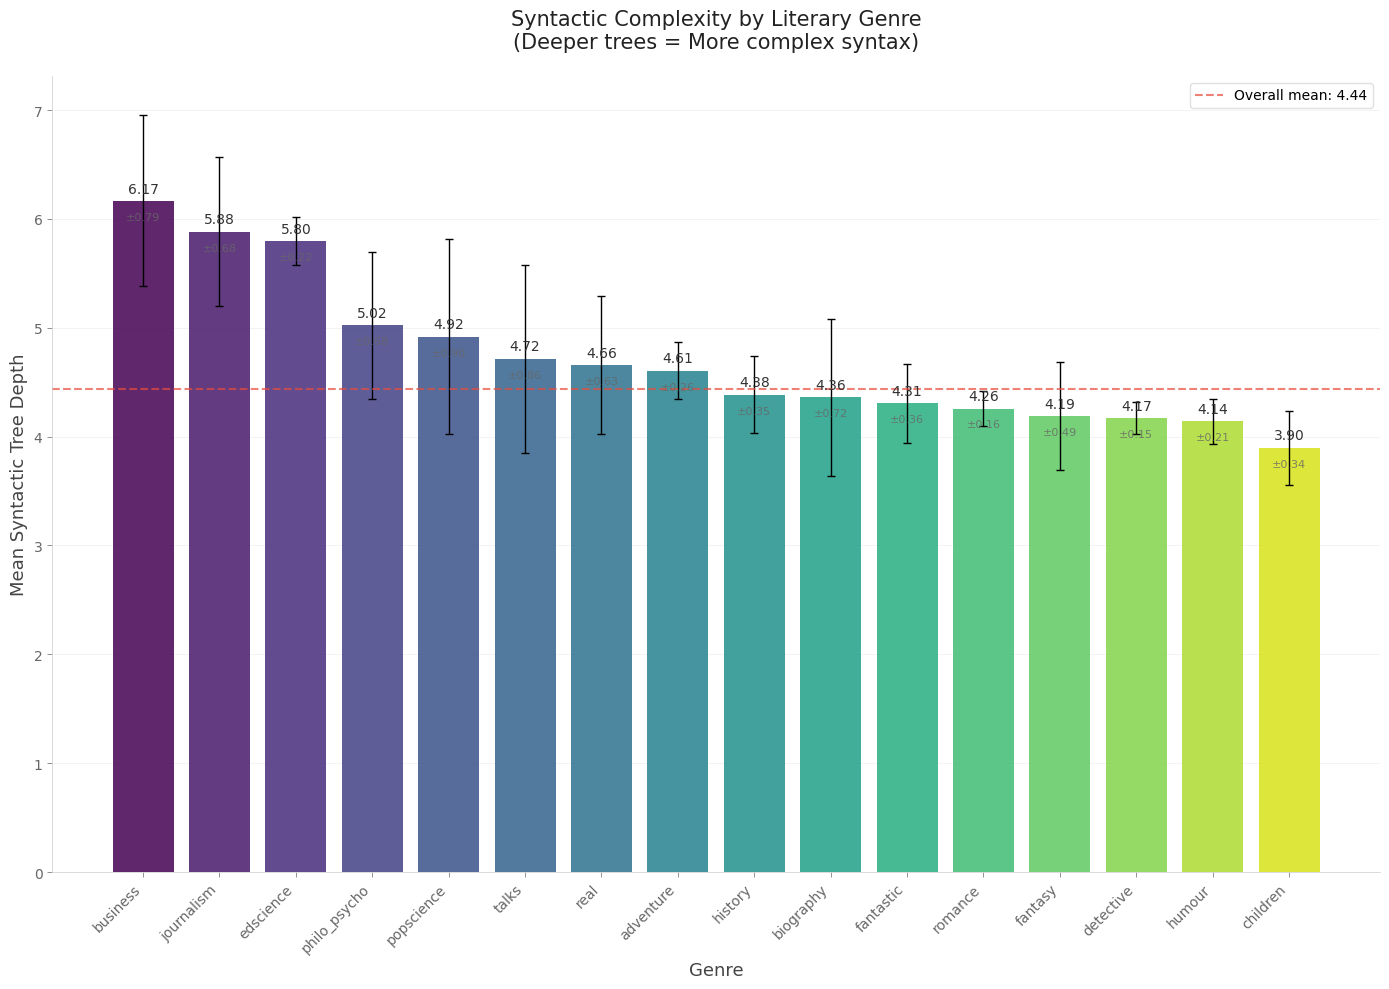

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Your genre mapping (same as before)
author_genres = {
    'children': [
        'Nosov', 'Volkov', 'Mikhalkov', 'Krapivin', 'Gaydar', 'Kassil',
        'Oseeva', 'Uspensky', 'Zhitkov', 'Oster', 'Dragunski', 'Prokofeva',
        'Rybakov', 'Abgaryan'
    ],
    'history': [
        'Simonov', 'Astafiev', 'Serafimovich', 'Furmanov', 'Sergeev-Tsenskij',
        'Kataev', 'Fadeev', 'Bykov', 'Chechin', 'Barinova', 'Marchik', 'Tamonikov'
    ],
    'fantastic': [
        'Adamov', 'Zemlyanoj', 'Efremov', 'Moshkov', 'Bushkov', 'Bulgakov',
        'Belyaev', 'Bulychev', 'AkuninBorisova', 'ShushpanovLouk'
    ],
    'fantasy': [
        'Lukyanenko', 'Zlotnikov', 'ZlotnikovNikolaev', 'Belyanin', 'Gelb',
        'Vlasova', 'Hoffman', 'Cherkasova', 'Shushpanov', 'Lungu', 'Salnikov'
    ],
    'detective': [
        'Derevyanko', 'Regentov', 'Akunin', 'Vainery', 'Marinina', 'Preobrazhensky', 'Strugatskie'
    ],
    'philo_psycho': [
        'Malevish', 'Epstein', 'Gusev', 'Losev', 'Makushinskiyi',
        'BonchOsmolovskaya', 'Aldanov', 'Dombrowski'
    ],
    'real': [
        'Dostoevsky', 'Tolstoy', 'Lermontov', 'SaltykovSchedrin', 'Mamin-Sibiryak',
        'Kuprin', 'Stepnova', 'Turgenev', 'Shukshin', 'Kozlov', 'Grekova'
    ],
    'humour': [
        'Zoschenko', 'Teffi', 'Voinovich', 'Aleshkovsky', 'Exler'
    ],
    'biography': [
        'Rubina', 'Aksakov', 'Chekhov', 'Gachev', 'Brustein', 'Granin', 'Dovlatov'
    ],
    'adventure': [
        'Soloviev', 'Solovyov', 'Pushkin', 'Grin', 'Kaverin', 'AkuninBrusnikin'
    ],
    'journalism': [
        'bashinform 202', 'VestnikRayona', 'pvlida', 'Gasymov', 'EdimDoma',
        'DoctorPiter', 'GazetaRu', 'nlobooks[ru]', 'GorVestnik', 'NakedScience','vestnik nsu', 'YasenevoMedia'
    ],
    'business': [
        'Vorotyntseva', 'Bobkova', 'Gusiatnikova', 'Kirsanova Anodina Aksenov'
    ],
    'popscience': [
        'Semihatov', 'Drobyshevsky', 'Shevtsov', 'Drobyshevsky Rupasova'
    ],
    'edscience': [
        'Gorelov', 'Alexander Hofman', 'Bakhtin', 'Knabe'
    ],
    'romance': [
        'Dubchak', 'Doronina', 'Mamina', 'Lubimova', 'Vladimirova'
    ],
    'talks': [
        'Convlab', 'TEDRus', 'Koni', 'Plevako'
    ]
}

# Read the Excel file
df = pd.read_excel('mean_depth_authors.xlsx')

# Create a mapping from author to genre
author_to_genre = {}
for genre, authors in author_genres.items():
    for author in authors:
        author_to_genre[author] = genre

# Add genre column to dataframe
df['genre'] = df['Author'].map(author_to_genre)

# Remove authors without genre mapping
df_with_genre = df.dropna(subset=['genre']).copy()

# Calculate mean depth per genre (weighted by number of books)
genre_stats = {}
for genre in author_genres.keys():
    genre_authors = df_with_genre[df_with_genre['genre'] == genre]
    if len(genre_authors) > 0:
        # Weighted average by number of books
        weighted_mean = np.average(genre_authors['Mean depth'], weights=genre_authors['Books'])
        genre_stats[genre] = {
            'mean_depth': weighted_mean,
            'std': np.std(genre_authors['Mean depth']),
            'num_authors': len(genre_authors),
            'total_books': genre_authors['Books'].sum(),
            'min_depth': genre_authors['Mean depth'].min(),
            'max_depth': genre_authors['Mean depth'].max()
        }

# Sort genres by mean depth
sorted_genres = sorted(genre_stats.items(), key=lambda x: x[1]['mean_depth'], reverse=True)

# ========== CREATE PRETTY HISTOGRAM WITH PASTEL1 PALETTE ==========
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

# Prepare data for plotting
genres = [g[0] for g in sorted_genres]
means = [g[1]['mean_depth'] for g in sorted_genres]
stds = [g[1]['std'] for g in sorted_genres]

# Get colors from Pastel1 colormap
pastel1 = plt.colormaps['viridis']
colors = [pastel1(i / len(genres)) for i in range(len(genres))]

# Create bars with softer styling
bars = ax.bar(genres, means, yerr=stds, capsize=3, color=colors, 
              edgecolor='none', alpha=0.85, 
              error_kw={'elinewidth': 1, 'markeredgewidth': 1, 'capthick': 1, 'color': '#888888'})

# Add value labels on top of bars with cleaner look
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=10, 
            fontweight='normal', color='#333333')
    ax.text(bar.get_x() + bar.get_width()/2., height - 0.1,
            f'±{std:.2f}', ha='center', va='top', fontsize=8, 
            color='#666666', alpha=0.8)

# Customize the plot with cleaner styling
ax.set_xlabel('Genre', fontsize=13, fontweight='normal', color='#444444')
ax.set_ylabel('Mean Syntactic Tree Depth', fontsize=13, fontweight='normal', color='#444444')
ax.set_title('Syntactic Complexity by Literary Genre\n(Deeper trees = More complex syntax)', 
             fontsize=15, fontweight='normal', pad=20, color='#222222')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10, color='#444444')

# Add subtle grid for better readability
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remove spines for cleaner look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')
    ax.spines[spine].set_linewidth(0.5)

# Add a horizontal line at overall mean
overall_mean = np.average(df_with_genre['Mean depth'], weights=df_with_genre['Books'])
ax.axhline(y=overall_mean, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Overall mean: {overall_mean:.2f}')
ax.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, 
          framealpha=0.9, edgecolor='#dddddd')

# Set y-axis to start at 0
ymax = max(means) + max(stds) + 0.25
ax.set_ylim(bottom=0, top=ymax)

# Style y-axis ticks
ax.tick_params(axis='y', colors='#666666', width=0.5)
ax.tick_params(axis='x', colors='#666666', width=0.5)

plt.tight_layout()

# Save the figure with high quality
plt.savefig('genre_depth_histogram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()